# RiMEA 02: Walking Speed on Upstairs

A single agent traverses a 10 m stair incline. RiMEA verifies that the model reproduces the assigned stair speed and notes that *"the user defines a speed factor"* for stairs. We model the stair as a planar 2 m corridor (extended to 30 m with 10 m run-up + 10 m buffer) carrying a **`speed_factor = 0.5` zone over the measured segment (x = 10–20)**, so the agent walks the run-up at the 1.0 m/s free speed and the stair at **0.5 m/s**, covering the 10 m incline in **20 s**. The same assigned speed applies up or down.

In [7]:
from datetime import datetime
print(f"Executed on {datetime.now().astimezone().strftime('%d %B %Y, %H:%M %Z')}")

Executed on 19 June 2026, 17:09 CEST


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pedpy
from shapely.geometry import Point, Polygon

from jupedsim_scenarios import load_scenario, run_scenario

In [9]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f7f7f5",
    "axes.edgecolor": "#3a3a3a",
    "axes.labelcolor": "#1d1d1d",
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "figure.figsize": (8, 5),
})

## Load and run the scenario

In [10]:
SCENARIO_ZIP = Path("scenario_files") / "Rimea-02-upstairs.zip"
scenario = load_scenario(str(SCENARIO_ZIP))
print(scenario.summary())
result = run_scenario(scenario, seed=42)

Scenario: /Users/elif/Desktop/HiWi/jupedsim-web-community/standards/rimea/scenario_files/Rimea-02-upstairs.zip
  Model:         CollisionFreeSpeedModel
  Seed:          42
  Max time:      60s
  Exits:         1
  Distributions: 1
  Stages:        0
  Zones:         1
  Journeys:      0
  Agents:        ~1
    jps-distributions_0: 1 agents
DEBUG: Distribution jps-distributions_0 RAW params from JSON: {'number': 1, 'radius': 0.15, 'v0': 1.0, 'distribution_mode': 'by_number', 'radius_distribution': 'constant', 'v0_distribution': 'constant', 'use_flow_spawning': False}
DEBUG: Distribution jps-distributions_0 processed params: {'number': 1, 'radius': 0.15, 'v0': 1.0, 'use_flow_spawning': False, 'flow_start_time': 0, 'flow_end_time': 10, 'use_premovement': False, 'premovement_distribution': 'gamma', 'premovement_param_a': None, 'premovement_param_b': None, 'premovement_seed': None, 'radius_distribution': 'constant', 'radius_std': None, 'v0_distribution': 'constant', 'v0_std': None, 'distrib

## Measure walking speed across the 10 m stair segment

The segment x = 10–20 sits inside the `speed_factor = 0.5` zone, so the expected stair speed is 0.5 m/s and the expected transit time is 20 s.

In [11]:
df = result.trajectory_dataframe().sort_values(['id', 'frame'])
MEAS_START_X = 10.0
MEAS_END_X = 20.0
DIRECTION = 'right'
rows = []
for agent_id, sub in df.groupby('id'):
    if DIRECTION == 'right':
        a = sub[sub.x >= MEAS_START_X]; b = sub[sub.x >= MEAS_END_X]
    else:
        a = sub[sub.x <= MEAS_START_X]; b = sub[sub.x <= MEAS_END_X]
    if a.empty or b.empty:
        continue
    t_in = a.iloc[0].frame / result.frame_rate
    t_out = b.iloc[0].frame / result.frame_rate
    rows.append({'id': int(agent_id), 't_in_s': t_in, 't_out_s': t_out, 'transit_s': t_out - t_in})
transit = pd.DataFrame(rows)
transit['speed_m_s'] = abs(MEAS_END_X - MEAS_START_X) / transit['transit_s']
transit

,id,t_in_s,t_out_s,transit_s,speed_m_s
0,2,8.8,28.8,20.0,0.5


## Plot trajectory x vs t

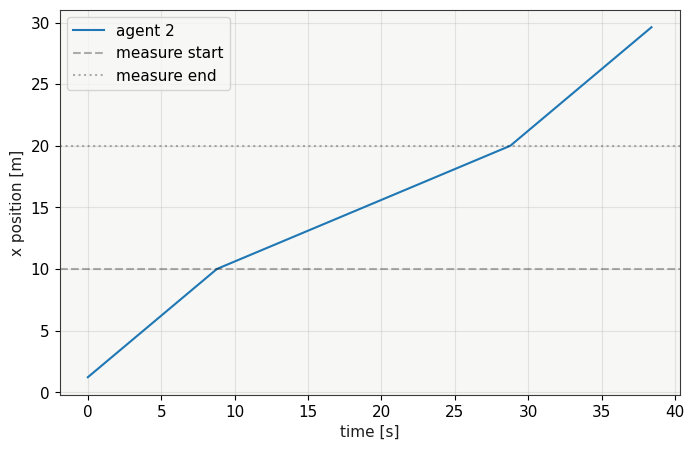

In [12]:
fig, ax = plt.subplots()
for agent_id, sub in df.groupby('id'):
    ax.plot(sub.frame / result.frame_rate, sub.x, label=f'agent {agent_id}')
ax.axhline(MEAS_START_X, color='k', ls='--', alpha=0.3, label='measure start')
ax.axhline(MEAS_END_X, color='k', ls=':', alpha=0.3, label='measure end')
ax.set_xlabel('time [s]'); ax.set_ylabel('x position [m]'); ax.legend()
plt.show()

## Acceptance

In [13]:
TARGET = 0.5  # 1.0 m/s free speed x speed_factor 0.5
TOL = 0.05
observed = transit['speed_m_s'].mean()
print(f'observed mean stair speed = {observed:.3f} m/s; target = {TARGET} m/s; '
      f'transit = {transit["transit_s"].mean():.2f} s; expected = 20 s')
assert abs(observed - TARGET) <= TOL, (observed, TARGET)
result.cleanup()

observed mean stair speed = 0.500 m/s; target = 0.5 m/s; transit = 20.00 s; expected = 20 s
